### LSTM Resume-Job Regression

This notebook trains a LSTM regressor on `resume_text` and `job_text` from `resume_data_cleaned.csv`.

Goals:
- keep the same `80/20` train/test split convention used in `regression_cleaned.ipynb`
- treat resume/job text as a true pair instead of collapsing them into one bag of words
- compare the final test result against the four regression baselines
- include deeper diagnostics: training curves, residual plots, score-bin analysis, and example inspection


In [5]:
# imports

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader

from lstm import (
    ResumeJobDataset,
    LSTMRegressor,
    build_vocab,
    collate_batch,
    fit_model,
    load_pretrained_embeddings,
    predict,
    regression_metrics,
    run_epoch,
    set_seed,
    tokenize_frame,
)

In [ ]:
# experiment configuration

DATA_PATH = Path('resume_data_cleaned.csv')
EMBED_PATH = Path('dan + predefined embeddings/embeddings/dolma_300_relativised.txt')

SEED = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.15  # fraction of the training split

MAX_VOCAB = 30000
MIN_FREQ = 1
MAX_RESUME_LEN = 256
MAX_JOB_LEN = 128
EMBED_DIM = 300
HIDDEN_SIZE = 128
DROPOUT = 0.25
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
EPOCHS = 20
PATIENCE = 4
FREEZE_EMBEDDINGS = False
USE_STRUCTURED_FEATURES = False
TINY_OVERFIT_ROWS = 128

STRUCT_COLS = [
    'num_skills',
    'num_degrees',
    'num_positions',
    'experience_years',
    'age_min',
    'age_max',
    'skill_jaccard',
]

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cpu


In [7]:
# load data and create stable splits

df = pd.read_csv(DATA_PATH)
for col in ['resume_text', 'job_text', 'combined_text']:
    df[col] = df[col].fillna('')

for col in STRUCT_COLS:
    df[col] = df[col].fillna(df[col].median())

train_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=VAL_SIZE, random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'loaded rows: {len(df)}')
print(f'train rows: {len(train_df)}')
print(f'val rows:   {len(val_df)}')
print(f'test rows:  {len(test_df)}')
print(f'target mean (train): {train_df["matched_score"].mean():.4f}')
print(f'target mean (test):  {test_df["matched_score"].mean():.4f}')

loaded rows: 9544
train rows: 6489
val rows:   1146
test rows:  1909
target mean (train): 0.6621
target mean (test):  0.6585


In [8]:
# build train-only vocabulary and pretrained embedding matrix

train_resume_tokens, train_job_tokens = tokenize_frame(train_df)
vocab = build_vocab(train_resume_tokens + train_job_tokens, max_vocab_size=MAX_VOCAB, min_freq=MIN_FREQ)
embedding_matrix, coverage = load_pretrained_embeddings(EMBED_PATH, vocab, EMBED_DIM)

resume_lengths = np.array([len(tokens) for tokens in train_resume_tokens])
job_lengths = np.array([len(tokens) for tokens in train_job_tokens])

print(f'vocab size: {len(vocab)}')
print(f'pretrained coverage: {coverage:.2%}')
print(f'resume token length median/p95: {np.median(resume_lengths):.0f} / {np.percentile(resume_lengths, 95):.0f}')
print(f'job token length median/p95: {np.median(job_lengths):.0f} / {np.percentile(job_lengths, 95):.0f}')

vocab size: 3904
pretrained coverage: 64.02%
resume token length median/p95: 82 / 168
job token length median/p95: 21 / 33


In [9]:
# datasets and dataloaders

struct_cols = STRUCT_COLS if USE_STRUCTURED_FEATURES else None

train_dataset = ResumeJobDataset(
    train_df,
    vocab=vocab,
    max_resume_len=MAX_RESUME_LEN,
    max_job_len=MAX_JOB_LEN,
    struct_cols=struct_cols,
)
val_dataset = ResumeJobDataset(
    val_df,
    vocab=vocab,
    max_resume_len=MAX_RESUME_LEN,
    max_job_len=MAX_JOB_LEN,
    struct_cols=struct_cols,
)
test_dataset = ResumeJobDataset(
    test_df,
    vocab=vocab,
    max_resume_len=MAX_RESUME_LEN,
    max_job_len=MAX_JOB_LEN,
    struct_cols=struct_cols,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

sample_batch = next(iter(train_loader))
print('sample batch shapes:')
for key, value in sample_batch.items():
    print(f'  {key}: {tuple(value.shape)}')

sample batch shapes:
  resume_ids: (64, 256)
  resume_len: (64,)
  job_ids: (64, 128)
  job_len: (64,)
  target: (64,)


In [ ]:
# train the full LSTM model with early stopping

model = LSTMRegressor(
    vocab_size=len(vocab),
    embedding_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    dropout=DROPOUT,
    embedding_matrix=embedding_matrix,
    freeze_embeddings=FREEZE_EMBEDDINGS,
    struct_dim=len(STRUCT_COLS) if USE_STRUCTURED_FEATURES else 0,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()

history, best_epoch, checkpoint_path = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE,
    checkpoint_path=CHECKPOINT_PATH,
)

history_df = pd.DataFrame(history)
print(f'best epoch: {best_epoch}')
print(f'checkpoint: {checkpoint_path}')
history_df.tail()

best epoch: 13
checkpoint: artifacts\lstm_best.pt


,epoch,train_loss,train_mse,train_mae,train_r2,val_loss,val_mse,val_mae,val_r2
12,13,0.021949,0.022001,0.117883,0.210798,0.020815,0.020796,0.114667,0.267736
13,14,0.022133,0.022112,0.118128,0.206828,0.021117,0.021097,0.117010,0.257134
14,15,0.021877,0.021845,0.117451,0.216418,0.021169,0.021149,0.116987,0.255285
15,16,0.021660,0.021680,0.116505,0.222334,0.021046,0.021027,0.116846,0.259601
16,17,0.022047,0.022053,0.117528,0.208940,0.020943,0.020918,0.113625,0.263447


In [12]:
# final test evaluation and baseline comparison

y_test, y_pred = predict(model, test_loader, device)
test_metrics = regression_metrics(y_test, y_pred)

baseline_results = {
    '1. combined_text tfidf': {'R2': 0.4938, 'MSE': 0.0140},
    '2. separate tfidf': {'R2': 0.4792, 'MSE': 0.0144},
    '3. structured only': {'R2': 0.0939, 'MSE': 0.0251},
    '4. hybrid (tfidf+struct)': {'R2': 0.5256, 'MSE': 0.0131},
}
baseline_results['5. lstm'] = {
    'R2': test_metrics['r2'],
    'MSE': test_metrics['mse'],
}

results_df = pd.DataFrame(baseline_results).T.sort_values('R2')
print('test metrics:')
print(pd.Series({
    'R2': test_metrics['r2'],
    'MSE': test_metrics['mse'],
    'MAE': test_metrics['mae'],
}).round(4).to_string())
results_df

test metrics:
R2     0.2910
MSE    0.0196
MAE    0.1110


,R2,MSE
3. structured only,0.093900,0.025100
5. lstm,0.290998,0.019606
2. separate tfidf,0.479200,0.014400
1. combined_text tfidf,0.493800,0.014000
4. hybrid (tfidf+struct),0.525600,0.013100


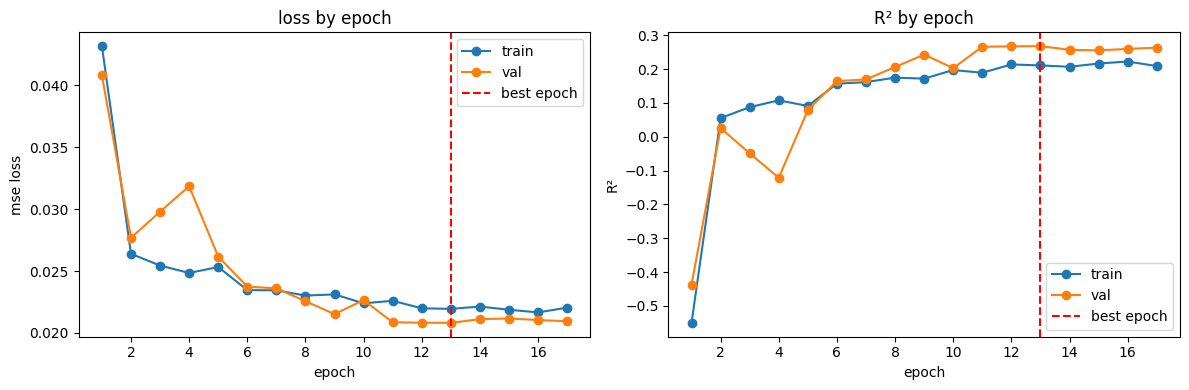

In [13]:
# training curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='val')
axes[0].axvline(best_epoch, color='red', linestyle='--', label='best epoch')
axes[0].set_title('loss by epoch')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('mse loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_r2'], marker='o', label='train')
axes[1].plot(history_df['epoch'], history_df['val_r2'], marker='o', label='val')
axes[1].axvline(best_epoch, color='red', linestyle='--', label='best epoch')
axes[1].set_title('R² by epoch')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('R²')
axes[1].legend()

plt.tight_layout()
plt.show()

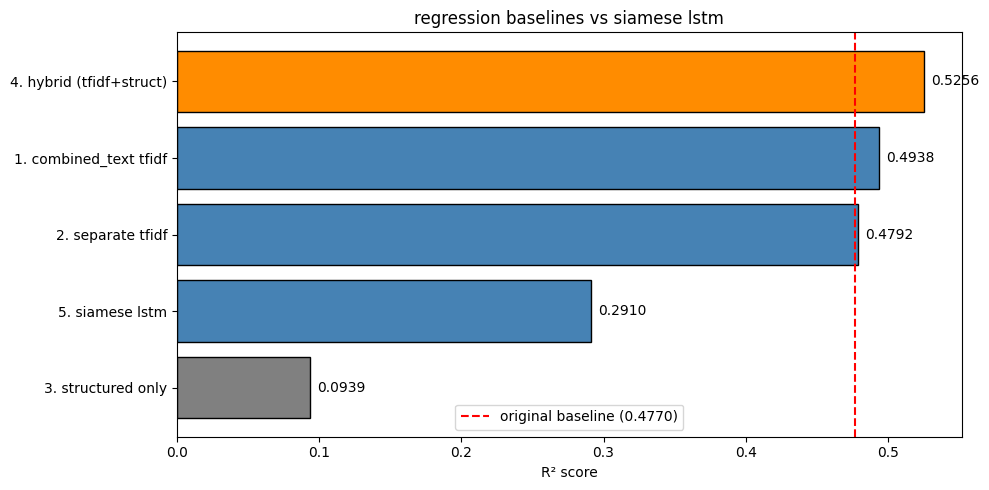

In [ ]:
# baseline comparison bar plot, matching regression_cleaned.ipynb style

fig, ax = plt.subplots(figsize=(10, 5))

labels = list(results_df.index)
r2_vals = results_df['R2'].values
colors = ['gray', 'steelblue', 'steelblue', 'steelblue', 'darkorange']

bars = ax.barh(labels, r2_vals, color=colors, edgecolor='black')
ax.axvline(x=0.4770, color='red', linestyle='--', label='original baseline (0.4770)')
ax.set_xlabel('R² score')
ax.set_title('regression baselines vs lstm')
ax.legend()

for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', va='center')

plt.tight_layout()
plt.show()

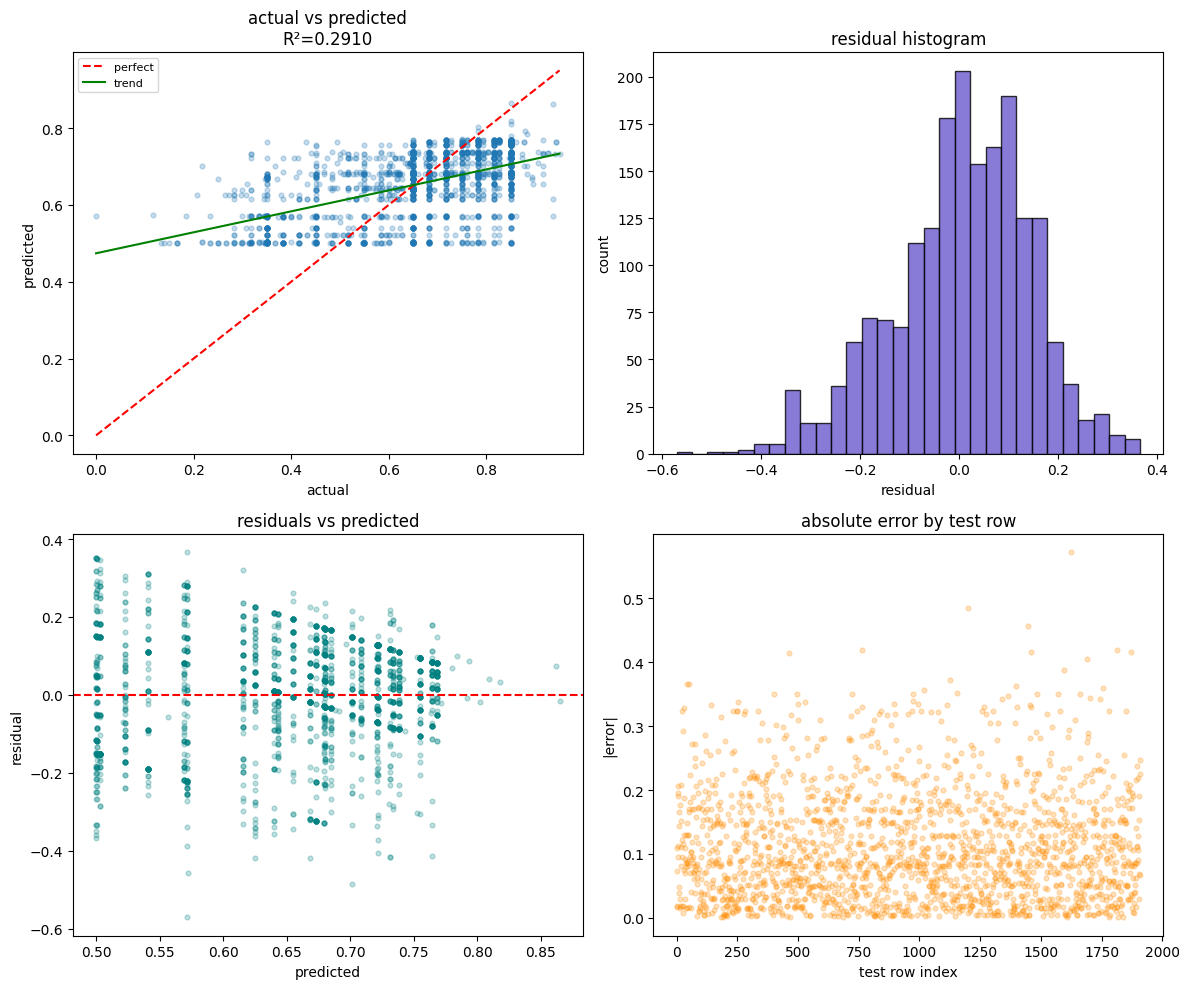

In [15]:
# prediction scatter and residual diagnostics

residuals = y_test - y_pred
m, b = np.polyfit(y_test, y_pred, 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(y_test, y_pred, alpha=0.25, s=12)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='perfect')
axes[0, 0].plot([y_test.min(), y_test.max()], [m * y_test.min() + b, m * y_test.max() + b], 'g-', label='trend')
axes[0, 0].set_title(f'actual vs predicted\nR²={test_metrics["r2"]:.4f}')
axes[0, 0].set_xlabel('actual')
axes[0, 0].set_ylabel('predicted')
axes[0, 0].legend(fontsize=8)

axes[0, 1].hist(residuals, bins=30, edgecolor='black', color='slateblue', alpha=0.8)
axes[0, 1].set_title('residual histogram')
axes[0, 1].set_xlabel('residual')
axes[0, 1].set_ylabel('count')

axes[1, 0].scatter(y_pred, residuals, alpha=0.25, s=12, color='teal')
axes[1, 0].axhline(0.0, color='red', linestyle='--')
axes[1, 0].set_title('residuals vs predicted')
axes[1, 0].set_xlabel('predicted')
axes[1, 0].set_ylabel('residual')

axes[1, 1].scatter(np.arange(len(residuals)), np.abs(residuals), alpha=0.25, s=12, color='darkorange')
axes[1, 1].set_title('absolute error by test row')
axes[1, 1].set_xlabel('test row index')
axes[1, 1].set_ylabel('|error|')

plt.tight_layout()
plt.show()

In [16]:
# score-bin analysis and example inspection

analysis_df = test_df[['resume_text', 'job_text', 'matched_score']].copy()
analysis_df['predicted_score'] = y_pred
analysis_df['residual'] = analysis_df['matched_score'] - analysis_df['predicted_score']
analysis_df['abs_error'] = analysis_df['residual'].abs()

analysis_df['score_bin'] = pd.cut(
    analysis_df['matched_score'],
    bins=[-0.001, 0.4, 0.7, 1.001],
    labels=['low (<=0.4)', 'mid (0.4-0.7)', 'high (>0.7)'],
)

bin_summary = analysis_df.groupby('score_bin', observed=False).agg(
    rows=('matched_score', 'size'),
    mean_actual=('matched_score', 'mean'),
    mean_pred=('predicted_score', 'mean'),
    mae=('abs_error', 'mean'),
    mse=('residual', lambda s: np.mean(np.square(s))),
)
display(bin_summary.round(4))

best_examples = analysis_df.nsmallest(5, 'abs_error')[['matched_score', 'predicted_score', 'abs_error', 'resume_text', 'job_text']]
worst_examples = analysis_df.nlargest(5, 'abs_error')[['matched_score', 'predicted_score', 'abs_error', 'resume_text', 'job_text']]

print('best predicted examples:')
display(best_examples)
print('worst predicted examples:')
display(worst_examples)

,rows,mean_actual,mean_pred,mae,mse
score_bin,,,,,
low (<=0.4),230,0.3302,0.5603,0.2300,0.0597
mid (0.4-0.7),812,0.6016,0.6397,0.0774,0.0101
high (>0.7),867,0.7989,0.6916,0.1108,0.0179


best predicted examples:


,matched_score,predicted_score,abs_error,resume_text,job_text
192,0.523333,0.522563,0.00077,i am fresher data analyst starting out in erp ...,business development executive bachelor/honors...
1817,0.683333,0.684493,0.00116,advertising architect asset management auditin...,devops engineer bachelor/honors at least 3 yea...
181,0.683333,0.684493,0.00116,associate solution advisor currently enrolled ...,devops engineer bachelor/honors at least 3 yea...
467,0.683333,0.684493,0.00116,data science data analytics database managemen...,devops engineer bachelor/honors at least 3 yea...
842,0.683333,0.684493,0.00116,requirement gathering software development dat...,devops engineer bachelor/honors at least 3 yea...


worst predicted examples:


,matched_score,predicted_score,abs_error,resume_text,job_text
1624,0.000000,0.571261,0.571261,"fresher with excellent communication, good ana...",head of internal control & compliance (icc) - ...
1201,0.216667,0.701268,0.484601,my full name is kailie marie mahea'lani gracii...,senior ios engineer bachelor of science (bsc) ...
1447,0.116667,0.572549,0.455883,"qa engineering software expertise - design, es...",site engineer bachelor of science (bsc) in civ...
1815,0.206667,0.625178,0.418512,fas asset accounting quickbooks anytime schedu...,data science engineer bachelor of science (bsc...
765,0.250000,0.668396,0.418396,desires an accounting position in a positive w...,data engineer bachelor of science (bsc) 5 to 8...
